# 03c - What the confidence number is worth

**No GPU. No Colab. This notebook runs on a laptop**, because `03b` saved the validation
logits and a `(2120, 27)` array of floats answers every question below.

This directly repairs an earlier mistake: `03_train.ipynb` measured its validation macro-F1
and then closed the runtime, and with it went every prediction behind that number - so asking
"how confident was it?" would have cost another GPU hour. Now it costs a file read.

Three questions:

1. **How is confidence distributed?** If everything is at 1.0, the field is useless for routing.
2. **Is the true label in the top 3 when it is not first?** That is the entire case for the
   `top3` field in the `predict()` contract.
3. **Coverage against accuracy.** Turns "send the uncertain ones to a human" into two numbers.

Calibration analysis (ECE, temperature scaling) was deliberately dropped from this project:
it is production-calibration work with no consumer in a course-scoped classifier, and every
threshold question asked here is answered by the coverage-accuracy curve.

**`clean/test` is not opened here.** Everything is on `clean/val`.


In [1]:
import json
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

REPO_ROOT = Path.cwd()
while not (REPO_ROOT / "src" / "data.py").exists() and REPO_ROOT != REPO_ROOT.parent:
    REPO_ROOT = REPO_ROOT.parent
assert (REPO_ROOT / "src" / "data.py").exists(), f"no repository found above {Path.cwd()}"
sys.path.insert(0, str(REPO_ROOT))

from src import confidence as C
from src import data as D
from src import evaluate as E

METRICS_DIR = REPO_ROOT / "results" / "metrics"
FIGURES_DIR = REPO_ROOT / "results" / "figures"
ERRORS_DIR  = REPO_ROOT / "results" / "errors"
for d in (METRICS_DIR, FIGURES_DIR, ERRORS_DIR):
    d.mkdir(parents=True, exist_ok=True)

print("repo:", REPO_ROOT.name)
print("python", sys.version.split()[0], "| numpy", np.__version__, "| pandas", pd.__version__)
print("\nno GPU needed - this notebook reads a saved logit matrix")

repo: support-triage
python 3.13.14 | numpy 2.5.1 | pandas 3.0.3

no GPU needed - this notebook reads a saved logit matrix


### Which run's predictions, and why it has to be named

A confidence threshold read off one model and applied to another is a threshold that fits
nothing. So the run id is read from the file name and carried into every table written below.

The logits used are those of the **frozen configuration** where available. If `03b` chose an
`r` whose logits were not saved, the seed-42 run at the resolution-floor `r` is used instead and
says so - reporting the wrong provenance loudly is better than reporting it silently.

In [2]:
freeze_path = REPO_ROOT / "artifacts" / "config_freeze.json"
FREEZE = json.loads(freeze_path.read_text()) if freeze_path.exists() else None
if FREEZE is None:
    print("!! artifacts/config_freeze.json is missing - run 03b_resolution_floor.ipynb first.")
else:
    print(f"frozen configuration : r={FREEZE['model']['r']}, "
          f"alpha={FREEZE['model']['lora_alpha']}, from {FREEZE['frozen_from_run']}")
    print(f"chosen by            : {FREEZE['selection']['reason']}")
    print(f"resolution floor     : {FREEZE['resolution_floor']['floor']:.6f} macro-F1 "
          f"at seed {FREEZE['resolution_floor']['seed']}")
    print(f"                       {FREEZE['resolution_floor']['limit']}")

available = sorted(METRICS_DIR.glob("val_logits_r*_seed*.npy"))
assert available, (
    f"no logit files in {METRICS_DIR}. Run 03b_resolution_floor.ipynb and commit its "
    "results/ before running this notebook.")
print()
print("logit matrices available:")
for p in available:
    print(f"  {p.name}")


frozen configuration : r=8, alpha=16, from run_04_lora_r8
chosen by            : the gap across r (0.0009) is larger than the resolution floor (0.0005), so the difference is at least expressible by the metric: r=8 leads by 1.9 validation rows' worth.
resolution floor     : 0.000477 macro-F1 at seed 42
                       this is metric resolution, not training variance - the project trains under one seed, so run-to-run spread was never measured and the true floor can only be larger

logit matrices available:
  val_logits_r8_seed42.npy


In [3]:
# Prefer the frozen r; fall back to whatever exists, and say which.
def parse(path):
    stem = path.stem.replace("val_logits_r", "")
    r_part, seed_part = stem.split("_seed")
    return int(r_part), int(seed_part)


wanted_r = FREEZE["model"]["r"] if FREEZE else None
matching = [p for p in available if parse(p)[0] == wanted_r]
chosen_path = min(matching or available, key=lambda p: parse(p)[1])
RUN_R, RUN_SEED = parse(chosen_path)

LOGITS = np.load(chosen_path)
RUN_ID = f"r{RUN_R}_seed{RUN_SEED}"
print(f"using {chosen_path.name}  ->  {LOGITS.shape}")
print(f"RUN_ID = {RUN_ID}")
if wanted_r is not None and RUN_R != wanted_r:
    print("\n" + "!" * 70)
    print(f"NOTE: the frozen configuration is r={wanted_r}, but no logits were saved")
    print(f"for it. These are r={RUN_R}. Every threshold below describes THAT model.")
    print("!" * 70)

splits = D.load_all_splits(REPO_ROOT / "data" / "processed")
clean_va = splits["clean"]["val"]
INTENTS = json.loads((REPO_ROOT / "artifacts" / "labels.json").read_text())
del splits["clean"]["test"], splits["naive"]["test"]

assert LOGITS.shape == (len(clean_va), len(INTENTS)), (
    f"logits are {LOGITS.shape} but clean/val is {len(clean_va)} x {len(INTENTS)}")
print(f"\nclean/val {len(clean_va):,} rows, {len(INTENTS)} intents - shapes agree")

using val_logits_r8_seed42.npy  ->  (2120, 27)
RUN_ID = r8_seed42

clean/val 2,120 rows, 27 intents - shapes agree


## 1 - How confidence is distributed

The basic check first: if every ticket comes back at 0.999, the field carries no information
and no threshold can separate anything. A fine-tuned classification head is expected to be
concentrated near 1.0 - the question is whether *anything* sits below it, and whether what
sits below it is where the errors are.

In [4]:
ROWS = C.row_frame(LOGITS, clean_va["intent"], INTENTS,
                   texts=clean_va["instruction"], row_ids=clean_va["row_id"])

print(ROWS[["confidence", "margin", "entropy"]].describe().round(4).to_string())
print(f"\naccuracy        {ROWS['correct'].mean():.4f}  "
      f"({(~ROWS['correct']).sum()} errors in {len(ROWS):,} rows)")

for threshold in (0.99, 0.95, 0.90, 0.50):
    below = (ROWS["confidence"] < threshold).sum()
    print(f"confidence < {threshold:<5}  {below:5d} rows  ({below / len(ROWS):6.2%})")

print("\nthe errors, and how confident the model was while making them:")
display(ROWS.loc[~ROWS["correct"],
                 ["instruction", "true", "predicted", "confidence", "margin", "top2"]])

       confidence     margin    entropy
count   2120.0000  2120.0000  2120.0000
mean       0.9987     0.9978     0.0055
std        0.0147     0.0252     0.0497
min        0.6300     0.3416     0.0000
25%        0.9999     0.9999     0.0001
50%        1.0000     1.0000     0.0002
75%        1.0000     1.0000     0.0006
max        1.0000     1.0000     1.1189

accuracy        0.9995  (1 errors in 2,120 rows)
confidence < 0.99      30 rows  ( 1.42%)
confidence < 0.95      12 rows  ( 0.57%)
confidence < 0.9        8 rows  ( 0.38%)
confidence < 0.5        0 rows  ( 0.00%)

the errors, and how confident the model was while making them:


,instruction,true,predicted,confidence,margin,top2
547,locate bill{{Invoice Number}},check_invoice,track_order,0.865833,0.733053,check_invoice


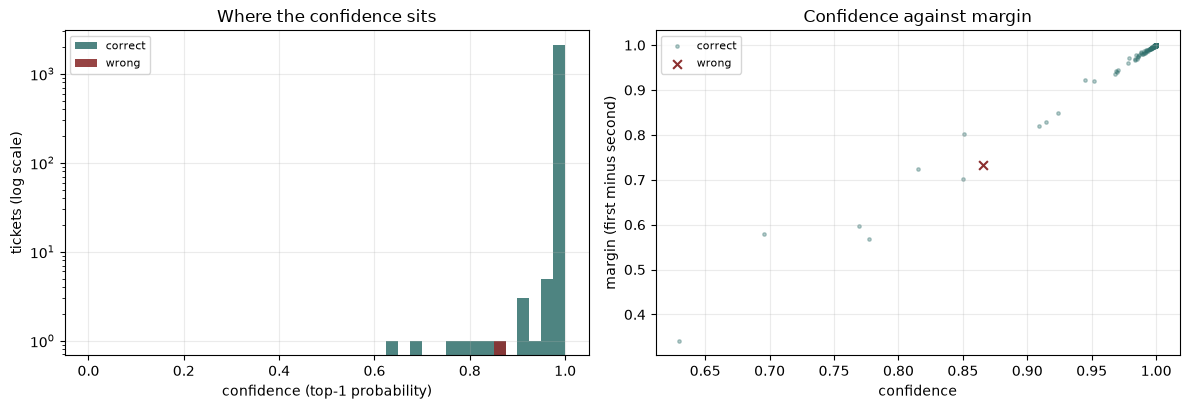

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))

ax = axes[0]
ax.hist(ROWS.loc[ROWS["correct"], "confidence"], bins=40, range=(0, 1),
        color="#2f6f6b", alpha=0.85, label="correct")
ax.hist(ROWS.loc[~ROWS["correct"], "confidence"], bins=40, range=(0, 1),
        color="#8c2f2f", alpha=0.9, label="wrong")
ax.set_yscale("log")          # log, or the handful of errors is invisible
ax.set_xlabel("confidence (top-1 probability)")
ax.set_ylabel("tickets (log scale)")
ax.set_title("Where the confidence sits")
ax.legend(fontsize=8); ax.grid(alpha=0.25)

ax = axes[1]
ax.scatter(ROWS.loc[ROWS["correct"], "confidence"],
           ROWS.loc[ROWS["correct"], "margin"],
           s=6, color="#2f6f6b", alpha=0.35, label="correct")
ax.scatter(ROWS.loc[~ROWS["correct"], "confidence"],
           ROWS.loc[~ROWS["correct"], "margin"],
           s=40, color="#8c2f2f", marker="x", label="wrong")
ax.set_xlabel("confidence"); ax.set_ylabel("margin (first minus second)")
ax.set_title("Confidence against margin")
ax.legend(fontsize=8); ax.grid(alpha=0.25)

fig.tight_layout()
fig.savefig(FIGURES_DIR / f"09_confidence_distribution_{RUN_ID}.png",
            dpi=150, bbox_inches="tight")
plt.show()

## 2 - Is the `top3` field worth returning?

A `top3` field - the three most likely intents, for when the model hesitates - is only worth
returning if the runner-up carries information. This is the measurement that says whether it
earns its place: if top-3 accuracy is meaningfully above top-1, the runner-up carries information and
a human handed three candidates is better off. If the two are equal, the field is honest and
useless - and reporting that is a finding, not an omission.

In [6]:
TOPK = C.topk_accuracy(LOGITS, clean_va["intent"], INTENTS, ks=(1, 2, 3, 5))
display(TOPK.round(4))

gain = float(TOPK.loc[TOPK["k"] == 3, "accuracy"].iloc[0]
             - TOPK.loc[TOPK["k"] == 1, "accuracy"].iloc[0])
recovered = int(TOPK.loc[TOPK["k"] == 1, "errors"].iloc[0]
                - TOPK.loc[TOPK["k"] == 3, "errors"].iloc[0])
print(f"\ntop-3 minus top-1: {gain:+.4f}  ({recovered} of "
      f"{int(TOPK.loc[TOPK['k'] == 1, 'errors'].iloc[0])} errors have the true label "
      "somewhere in the top three)")
print("\nRead this honestly: with an error count this small the difference between")
print("top-1 and top-3 is a handful of tickets either way, and the field's value")
print("is a judgement about the routing stage rather than a number this can settle.")

,k,accuracy,errors
0,1,0.9995,1
1,2,1.0000,0
2,3,1.0000,0
3,5,1.0000,0



top-3 minus top-1: +0.0005  (1 of 1 errors have the true label somewhere in the top three)

Read this honestly: with an error count this small the difference between
top-1 and top-3 is a handful of tickets either way, and the field's value
is a judgement about the routing stage rather than a number this can settle.


## 3 - Coverage against accuracy

The bridge to the routing stage that has not been built yet. For each confidence threshold:
how many tickets does the system answer, and how well does it answer them.

`accuracy_abstained` is the honest column. If the tickets held back are answered correctly just
as often as the ones let through, the threshold is not selecting doubt - it is throwing away
work for nothing.

In [7]:
COVERAGE = C.coverage_accuracy_curve(LOGITS, clean_va["intent"], INTENTS)
display(COVERAGE.round(4))

full = COVERAGE.loc[COVERAGE["threshold"] == 0.0].iloc[0]
print(f"answering everything: {full['coverage']:.1%} coverage at "
      f"{full['accuracy_covered']:.4f} accuracy, {full['errors_covered']} errors\n")

clean = COVERAGE[(COVERAGE["errors_covered"] == 0) & (COVERAGE["n_answered"] > 0)]
if not clean.empty:
    row = clean.loc[clean["coverage"].idxmax()]
    print(f"the most permissive threshold with NO errors let through: "
          f"{row['threshold']}")
    print(f"  answers {row['coverage']:.1%} of tickets ({int(row['n_answered'])}) with "
          f"{int(row['errors_covered'])} errors")
    print(f"  defers {int(row['n_deferred'])} tickets to a human")
else:
    print("no threshold in the sweep removes every error.")

,threshold,coverage,n_answered,n_deferred,accuracy_covered,accuracy_abstained,errors_covered
0,0.0000,1.0000,2120,0,0.9995,NaN,1
1,0.5000,1.0000,2120,0,0.9995,NaN,1
2,0.7000,0.9991,2118,2,0.9995,1.0000,1
3,0.8000,0.9981,2116,4,0.9995,1.0000,1
4,0.9000,0.9962,2112,8,1.0000,0.8750,0
5,0.9500,0.9943,2108,12,1.0000,0.9167,0
6,0.9900,0.9858,2090,30,1.0000,0.9667,0
7,0.9950,0.9807,2079,41,1.0000,0.9756,0
8,0.9990,0.9590,2033,87,1.0000,0.9885,0
9,0.9999,0.8274,1754,366,1.0000,0.9973,0


answering everything: 100.0% coverage at 0.9995 accuracy, 1.0 errors

the most permissive threshold with NO errors let through: 0.9
  answers 99.6% of tickets (2112) with 0 errors
  defers 8 tickets to a human


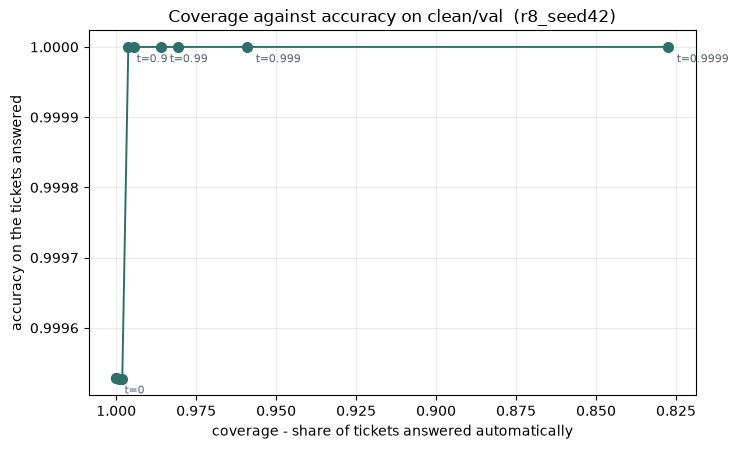

In [8]:
fig, ax = plt.subplots(figsize=(7.5, 4.6))
plot = COVERAGE[COVERAGE["coverage"] > 0].copy()

ax.plot(plot["coverage"], plot["accuracy_covered"], "o-",
        color="#2f6f6b", linewidth=1.4, markersize=7)
for _, row in plot.iterrows():
    if row["threshold"] in (0.0, 0.9, 0.99, 0.999, 0.9999):
        ax.annotate(f"t={row['threshold']:g}",
                    (row["coverage"], row["accuracy_covered"]),
                    textcoords="offset points", xytext=(6, -11), fontsize=8,
                    color="#5c6470")
ax.set_xlabel("coverage - share of tickets answered automatically")
ax.set_ylabel("accuracy on the tickets answered")
ax.set_title(f"Coverage against accuracy on clean/val  ({RUN_ID})")
ax.grid(alpha=0.25)
ax.invert_xaxis()   # left-to-right reads as "raise the threshold"

fig.tight_layout()
fig.savefig(FIGURES_DIR / f"10_coverage_accuracy_{RUN_ID}.png", dpi=150,
            bbox_inches="tight")
plt.show()

## 5 - Write everything down

Every file carries the run id in its name. A threshold read off one model and applied to
another fits nothing, and three days later the only thing that says which model a table
describes is the file name.

In [9]:
ROWS.to_csv(METRICS_DIR / f"confidence_rows_{RUN_ID}.csv", index=False)
TOPK.to_csv(METRICS_DIR / f"topk_accuracy_{RUN_ID}.csv", index=False)
COVERAGE.to_csv(METRICS_DIR / f"coverage_accuracy_{RUN_ID}.csv", index=False)
ROWS.loc[~ROWS["correct"]].to_csv(ERRORS_DIR / f"confidence_errors_{RUN_ID}.csv",
                                  index=False)

summary = {
    "run_id": RUN_ID,
    "r": RUN_R,
    "train_seed": RUN_SEED,
    "scored_on": "clean/val",
    "n_rows": int(len(ROWS)),
    "accuracy": float(ROWS["correct"].mean()),
    "mean_confidence": float(ROWS["confidence"].mean()),
    "median_confidence": float(ROWS["confidence"].median()),
    "rows_below_0.99": int((ROWS["confidence"] < 0.99).sum()),
    "top1_accuracy": float(TOPK.loc[TOPK["k"] == 1, "accuracy"].iloc[0]),
    "top3_accuracy": float(TOPK.loc[TOPK["k"] == 3, "accuracy"].iloc[0]),
}
D.write_json(summary, METRICS_DIR / f"confidence_summary_{RUN_ID}.json")
print(json.dumps(summary, indent=2))


{
  "run_id": "r8_seed42",
  "r": 8,
  "train_seed": 42,
  "scored_on": "clean/val",
  "n_rows": 2120,
  "accuracy": 0.9995283018867924,
  "mean_confidence": 0.9987160685779368,
  "median_confidence": 0.999987349703056,
  "rows_below_0.99": 30,
  "top1_accuracy": 0.9995283018867924,
  "top3_accuracy": 1.0
}


## 6 - What this says, and what it does not

**For the report.**

- The confidence distribution and the coverage-accuracy curve are what turn a single headline
  macro-F1 into a statement about individual predictions. They are measurements rather than
  promises.
- Whether `top3` is worth returning at all is now a number rather than an assumption - and with
  an error count this small, the honest answer may well be "it cannot be settled from this
  validation set", which is worth saying plainly.

**The limit that has to be stated with all of it.** A high confidence means "of these 27
intents, this one is most likely" - never "this ticket is one of the 27". A message about
something the taxonomy has no label for still gets a label, possibly a confident one, because a
classification head cannot answer "none of these". That is a stated limitation of the system as
built, and where to put a cutoff is an operational decision this project leaves open.

**And the limit that comes from the data.** These numbers sit on `clean/val`, whose near
duplicates were removed in `01_data.ipynb`. Confidence measured on a set built to contain no
siblings of the training rows is an optimistic estimate of confidence on live tickets, which
arrive with no such guarantee. The naive-split comparison in `04_test.ipynb` is what puts a
size on that gap.